# Цель проекта
### Цель проекта — закрепить понимание принципов работы алгоритмов деревьев решений, ансамблей и кластеризации через собственную реализацию и анализ их поведения на данных.

В ходе проекта вы:

1. реализуете базовые версии алгоритмов с нуля, используя numpy и pandas;
2. проведёте эксперименты с параметрами и сравните результаты с реализациями из sklearn;
3. научитесь интерпретировать результаты и визуализировать их.

## Этап 1. Реализация дерева решений (15 баллов)
На этом этапе вы создаёте простую реализацию дерева решений для задачи классификации.

#### Что нужно сделать
1. Сгенерируйте небольшой набор данных (100–300 наблюдений).
2. Преобразуйте данные в pandas.DataFrame.

3. Реализуйте функции:

$\hspace{0.6cm}$ 3.1. расчёта критерия Джини или энтропии;

$\hspace{0.6cm}$ 3.2. поиска наилучшего разбиения по признаку;

$\hspace{0.6cm}$ 3.3. рекурсивного построения дерева с ограничением по глубине (max_depth) или по числу объектов в узле (min_samples_split);

$\hspace{0.6cm}$ 3.4. предсказания для новых наблюдений.
#### Тестирование модели
1. Разделите данные на обучающую и тестовую выборки (например, с помощью train_test_split, зафиксировав random_state=42 для воспроизводимости).

2. Сравните результаты своей реализации с DecisionTreeClassifier из sklearn. Разрешается использовать этот класс только для сверки корректности.

3. Постройте график границ решений (если данных 2D) с помощью matplotlib.
#### Результат
1. Таблица с точностью (accuracy) на обучении и тесте.

2. Визуализация дерева или границ решений.

3. Краткий комментарий о различиях вашей реализации и sklearn.

#### Решение
1. Генерируем набор данных в соответсвии с заданием

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

X, y = make_classification(
    n_samples=200,
    n_features=2,  # два признака для наглядной визуализации границ решений
    n_informative=2,
    n_redundant=0,
    random_state=42
)

2. Преобразуем данные в датафрейм

In [155]:
trees_task_data = pd.DataFrame({
    'feature_1' : X[:,0],
    'feature_2' : X[:,1], 
    'label' : y
})

In [156]:
trees_task_data.head()

,feature_1,feature_2,label
0,1.689767,-1.408241,1
1,1.530287,-1.459848,1
2,-1.175042,-1.447633,0
3,-2.585395,0.963532,0
4,1.372246,0.440695,1


3. Реализуем функции

$\hspace{0.6cm}$ 3.1. Функция расчета энтропии

In [157]:
def entropy(y):
    p = y.value_counts(normalize=True)
    entropy = -np.sum(p * np.log2(p))
    return entropy

$\hspace{0.6cm}$ 3.2. Функция поиска наилучшего разбиения по признаку 

$\hspace{1cm}$ 3.2.1. Функция определения кандидатов в параметры предиката

In [158]:
def find_candidates_for_thresholds(x, y):
    x = x.sort_values().drop_duplicates()
    x_roll_mean = x.rolling(2).mean().dropna()
    y = y[x_roll_mean.index]
    y_roll_mean = y.diff()
    candidates = x_roll_mean[y_roll_mean != 0]
    return candidates.values

$\hspace{1cm}$ 3.2.2. Функция разбиения выборки по предикату на левую и правую части

In [159]:
def split(X, y, split_params):
    j, t = split_params
    predicat = X.iloc[:, j] <= t
    X_left, y_left = X[predicat], y[predicat]
    X_right, y_right = X[~predicat], y[~predicat]
    return X_left, y_left, X_right, y_right

$\hspace{1cm}$ 3.2.3. Функция расчета взвешенной неоднородности после разбиения

In [161]:
def calculate_weighted_impurity(X, y, split_params, criterion):
    X_left, y_left, X_right, y_right = split(X, y, split_params)
    N, N_left, N_right  = y.size, y_left.size, y_right.size
    score = N_left / N * criterion(y_left) + N_right / N * criterion(y_right)
    return score

$\hspace{1cm}$ 3.2.4. Функция поиска наилучшего разбиения по признаку

In [162]:
def best_split(X, y, criterion):
    M = X.shape[1]
    min_weighted_impurity = np.inf
    optimal_split_params = None
    for j in range(M):
        thresholds = find_candidates_for_thresholds(X.iloc[:, j], y)
        for t in thresholds:
            split_params = (j, t)
            weighted_impurity = calculate_weighted_impurity(X, y, split_params, criterion)
            if weighted_impurity < min_weighted_impurity:
                min_weighted_impurity = weighted_impurity
                optimal_split_params = split_params
    return optimal_split_params

3.3. Функция рекурсивного построения дерева с ограничением по глубине.

$\hspace{0.6cm}$ 3.3.1. Класс вершины

$\hspace{0.6cm}$ Атрибуты класса:

$\hspace{0.6cm}$ left — ссылка на левого потомка;

$\hspace{0.6cm}$ right — ссылка на правого потомка;

$\hspace{0.6cm}$ value — ответ алгоритма;

$\hspace{0.6cm}$ split_params — параметры разбиения (сплита);

$\hspace{0.6cm}$ impurity — неоднородность в вершине (пригодится для расчёта важности признаков);

$\hspace{0.6cm}$ samples — количество объектов, попавших в вершину;

$\hspace{0.6cm}$ is_leaf — булева переменная, которая указывает, является ли вершина листовой.

In [163]:
class Node:
    def __init__(self, left=None, 
                 right=None, value=None, 
                 split_params=None, impurity=None,
                 samples=None, is_leaf=False):
        self.left = left
        self.right = right
        self.split_params = split_params
        self.value = value
        self.impurity = impurity
        self.samples = samples
        self.is_leaf = is_leaf

$\hspace{1cm}$ 3.3.2. Функция расчета самого популярного класса

In [164]:
def create_leaf_prediction(y):
    value = y.mode()[0]
    return value

$\hspace{1cm}$ 3.3.3. Функция расчета критерия остановки

In [165]:
def stopping_criterion(X, y, criterion, max_depth=None, depth=0):
    if max_depth is None:
        return (criterion(y) == 0) 
    else:
        return (criterion(y) == 0) or (depth > max_depth)

$\hspace{0.6cm}$ 3.3.4. Функция рекурсивного построения дерева решений с ограничением по глубине дерева

In [166]:
def build_decision_tree(X, y, criterion, max_depth=None, depth=0):
    depth += 1
    if stopping_criterion(X, y, criterion, max_depth, depth):
        value = create_leaf_prediction(y)
        node = Node(
            value=value, 
            impurity=criterion(y), 
            samples=y.size,
            is_leaf=True
        )
    else:
        split_params = best_split(X, y, criterion=entropy)
        X_left, y_left, X_right, y_right = split(X, y, split_params)
        left = build_decision_tree(X_left, y_left, criterion, max_depth, depth)
        right = build_decision_tree(X_right, y_right, criterion, max_depth, depth)       
        node = Node(
            left=left, right=right, 
            split_params=split_params, 
            impurity=criterion(y), 
            samples=y.size
        )
    return node

3.4. Функция предсказания для новых наблюдений

$\hspace{0.6cm}$ 3.4.1. Функция предсказания для одного наблюдения

In [167]:
def predict_sample(node, x):
    if node.is_leaf:
        return node.value
    j, t = node.split_params
    if x[j] <= t:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)

$\hspace{0.6cm}$ 3.4.2. Функция предсказания для всех объектов выборки.

In [168]:
def predict(decision_tree, X):
    predictions = [predict_sample(decision_tree, x) for x in X.values]
    return np.array(predictions)

4. Тестирование модели

$\hspace{0.6cm}$ 4.1. Разделение данных на обучающую и тестовую выборки

In [169]:
# Формируем обучающую и тестовую выборки
X_train, X_test, y_train, y_test = model_selection.train_test_split(trees_task_data[['feature_1','feature_2']], trees_task_data['label'], test_size=0.2, stratify=y, random_state=42)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (160, 2)
Test shape: (40, 2)


$\hspace{0.6cm}$ 4.2. Построение дерева решений на обучающей выборке с помощью написанных функций

In [170]:
decision_tree = build_decision_tree(X_train, y_train, criterion=entropy)

$\hspace{0.6cm}$ 4.3. Предсказание целевой переменной и проверка точности на обучающей и тестовой выборке 

In [171]:
y_train_pred = predict(decision_tree, X_train)

y_test_pred = predict(decision_tree, X_test)

print('Training accuracy: {:.3f}'.format(metrics.accuracy_score(y_train, y_train_pred)))
print('Test accuracy: {:.3f}'.format(metrics.accuracy_score(y_test, y_test_pred)))

Training accuracy: 1.000
Test accuracy: 0.875


$\hspace{0.6cm}$ 4.4. Построение графика границ решений для дерева, построенного по написанным функциям

In [172]:
# Функция визуализации границ решений 
def plot_decision_bound_regression_manual(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    X_net = pd.DataFrame(X_net)
    y_pred = predict(decision_tree, X_net)
    y_pred = y_pred.reshape(xx1.shape)
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], s=15, color='black', alpha=0.8)
    contour = plt.contourf(xx1, xx2, y_pred, 10, cmap='cividis', alpha=0.5)
    fig.colorbar(contour)


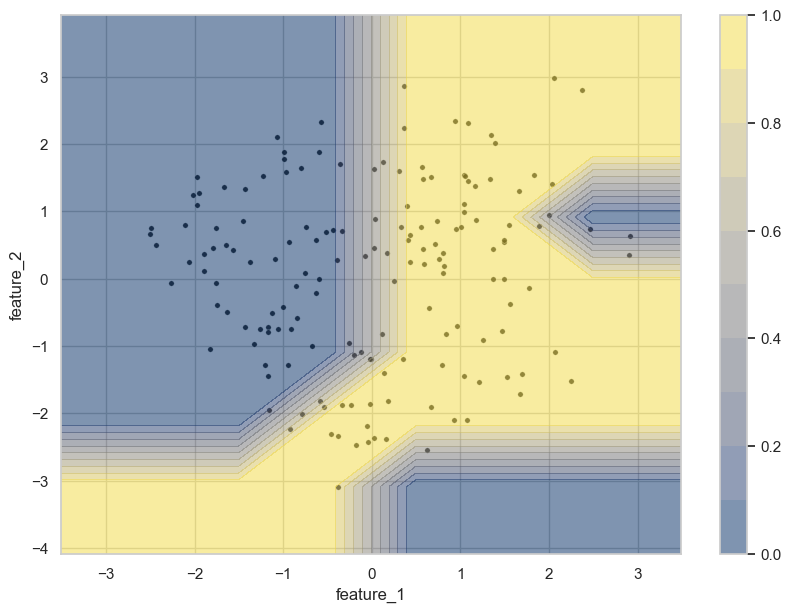

In [173]:

# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (10, 7))
plot_decision_bound_regression_manual(X_train, y_train, decision_tree, fig)

$\hspace{0.6cm}$ 4.5. Построение дерева решений с помощью DecisionTreeClassifier из sklearn

In [174]:
# Инициализируем модель дерева решений и обучаем ее
dt = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    random_state=0 #генератор случайных чисел
)
dt.fit(X_train, y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


$\hspace{0.6cm}$ 4.6. Предсказание целевой переменной и проверка точности на тестовой выборке деревом решений из DecisionTreeClassifier из sklearn

In [175]:

y_train_pred = dt.predict(X_train)

y_test_pred = dt.predict(X_test)

print('Training accuracy: {:.3f}'.format(metrics.accuracy_score(y_train, y_train_pred)))
print('Test accuracy: {:.3f}'.format(metrics.accuracy_score(y_test, y_test_pred)))

Training accuracy: 1.000
Test accuracy: 0.850


$\hspace{0.6cm}$ 4.7. Построение графика границ решений

c:\Users\troyd\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


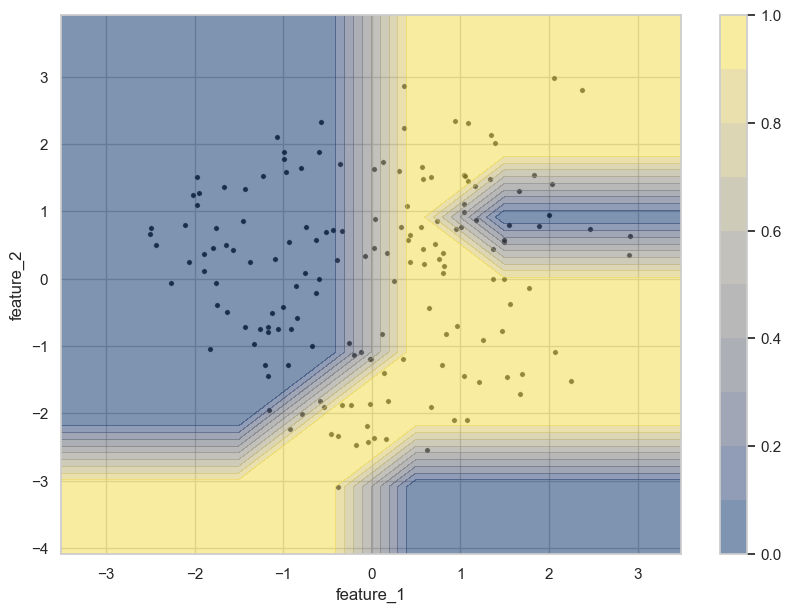

In [176]:
def plot_decision_bound_regression(X, y, model, fig):
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 1)
    )
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    y_pred = model.predict(X_net)
    y_pred = y_pred.reshape(xx1.shape)
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], s=15, color='black', alpha=0.8)
    contour = plt.contourf(xx1, xx2, y_pred, 10, cmap='cividis', alpha=0.5)
    fig.colorbar(contour)

# Визуализируем разделяющую поверхность дерева решений
fig = plt.figure(figsize = (10, 7))
plot_decision_bound_regression(X_train, y_train, dt, fig)

##### 5. Результат

 5.1. Таблица с точностью (accuracy) на обучении и тесте при построении дерева "вручную".
$$
\begin{array}{|c|c|}
\hline \text{Training accuracy} & 1.000 \\
\hline \text{Test accuracy} & 0.875 \\
\hline
\end{array}
$$

 5.2. Таблица с точностью (accuracy) на обучении и тесте при построении дерева с помощью sklearn.
$$
\begin{array}{|c|c|}
\hline \text{Training accuracy} & 1.000 \\
\hline \text{Test accuracy} & 0.850 \\
\hline
\end{array}
$$

 5.3. Визуализация границ решений.

 Визуализация границ решений представлена в пунктах 4.4. и 4.7. (см. выше).

 5.4. Краткий комментарий о различиях вашей реализации и sklearn.

 В рамках выполнения задания были построены две модели дерева решений. Первая модель реализована "вручную", вторая с помощью библиотеки sklearn. Реализация с помощью готовой 
 библиотеки более быстрая и удобная, однако при реализации "вручную" становится возможно заглянуть внутрь процесса построения дерева решений и понять необходимые шаги. Обе модели  одинаково точно описывают значения обучающей (Training) выборки, что видно из таблиц в п. 5.1. и п. 5.2. Небольшие расхождения в точности наблюдаются при проверке моделей на  тестовой (Test) выборке: 87.5 % для дерева, построенного "вручную", 85 % для дерева, построенного с помощью sklearn. Разница незначительна и может быть связана с отличиями 
 алгоритмов построения моделей.



# Этап 2. Ансамбль деревьев (бэггинг) (15 баллов)

Теперь вы используете свою реализацию дерева для построения ансамбля.

Что нужно сделать
1. Напишите функцию, которая:

случайно выбирает bootstrap-выборку (с возвращением) из обучающих данных размером, равным обучающей выборке;

обучает на ней одно дерево решений;

сохраняет модель.

2. Повторите процесс несколько раз — например, для N = 5, 10, 20.

3. Для объединения предсказаний:

при классификации используйте большинство голосов;

если реализуете предсказания вероятностей, усредняйте вероятности по всем деревьям и выбирайте класс с наибольшим средним значением.

4. Чтобы результаты были воспроизводимыми, фиксируйте random_state при генерации каждой подвыборки (например, random_state=i внутри цикла).

5. Сравните качество классификации одного дерева и ансамбля.

6. Постройте график зависимости точности от количества деревьев.

Результат
Таблица с результатами для разных N.

График зависимости качества от числа деревьев.

Вывод: как ансамбль влияет на качество и устойчивость модели.

#### Решение

2.1. Функция, случайно выбирающая бутстрэп-выборку (с возвращением) из обучающих данных размером, равным обучающей выборке. И обучает и созраняет модель одного дерева решений.

In [177]:
def bootstrap_bagging(X_train,y_train, random_state=42):

    rng = np.random.RandomState(random_state)
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    
    X_train_bootstrap = X_train.iloc[idx].reset_index(drop=True)
    y_train_bootstrap = y_train.iloc[idx].reset_index(drop=True)
    
    bootstrap_tree = build_decision_tree(X_train_bootstrap, y_train_bootstrap, criterion=entropy)
    
    return X_train_bootstrap, y_train_bootstrap, bootstrap_tree
    

In [178]:
X_train_bootstrap, y_train_bootstrap, bootstrap_tree = bootstrap_bagging(X_train,y_train)

In [179]:
y_train_pred = predict(bootstrap_tree, X_train)

y_test_pred = predict(bootstrap_tree, X_test)

print('Training accuracy: {:.3f}'.format(metrics.accuracy_score(y_train, y_train_pred)))
print('Test accuracy: {:.3f}'.format(metrics.accuracy_score(y_test, y_test_pred)))

Training accuracy: 0.919
Test accuracy: 0.875


2.2. Функция для построения ансамбля деревьев.

In [180]:
def bootstrap_forest(X_train, y_train, n_trees=5, base_random_state=42):
    trees = []
    for i in range(n_trees):
        _,_,tree = bootstrap_bagging( X_train, y_train,
            random_state=base_random_state + i,  # разный сид для каждого дерева
            )
        trees.append(tree)
    return trees

2.2.1. Построение моделей деревьев для N = 5, 10, 20.

In [181]:
trees_5  = bootstrap_forest(X_train, y_train, n_trees=5)
trees_10 = bootstrap_forest(X_train, y_train, n_trees=10)
trees_20 = bootstrap_forest(X_train, y_train, n_trees=20)

2.2.1. Функция, объединяющая предсказания леса деревьев методом большинства голосов.

In [182]:
def predict_with_voting(trees, X):
    # 1. Получаем матрицу предсказаний: (n_samples, n_trees)
    # Транспонируем (.T), чтобы строки стали объектами, а столбцы — голосами деревьев
    preds = np.array([predict(tree, X) for tree in trees]).T
    
    final_preds = []
    
    # 2. Проходим по каждому объекту
    for sample_votes in preds:

        counts = np.bincount(sample_votes.astype(int))
        
        winner = np.argmax(counts)
        final_preds.append(winner)
        
    return np.array(final_preds)


In [183]:
y_train_pred_trees_5 = predict_with_voting(trees_5, X_train_bootstrap)

y_test_pred_trees_5 = predict_with_voting(trees_5, X_test)

print('Training accuracy: {:.3f}'.format(metrics.accuracy_score(y_train_bootstrap, y_train_pred_trees_5)))
print('Test accuracy: {:.3f}'.format(metrics.accuracy_score(y_test, y_test_pred_trees_5)))

Training accuracy: 1.000
Test accuracy: 0.825


In [184]:
y_train_pred_trees_10 = predict_with_voting(trees_10, X_train_bootstrap)

y_test_pred_trees_10 = predict_with_voting(trees_10, X_test)

print('Training accuracy: {:.3f}'.format(metrics.accuracy_score(y_train_bootstrap, y_train_pred_trees_10)))
print('Test accuracy: {:.3f}'.format(metrics.accuracy_score(y_test, y_test_pred_trees_10)))

Training accuracy: 1.000
Test accuracy: 0.825


In [185]:
y_train_pred_trees_20 = predict_with_voting(trees_20, X_train_bootstrap)

y_test_pred_trees_20 = predict_with_voting(trees_20, X_test)

print('Training accuracy: {:.3f}'.format(metrics.accuracy_score(y_train_bootstrap, y_train_pred_trees_20)))
print('Test accuracy: {:.3f}'.format(metrics.accuracy_score(y_test, y_test_pred_trees_20)))

Training accuracy: 1.000
Test accuracy: 0.825


3. График зависимости точности от количества деревьев

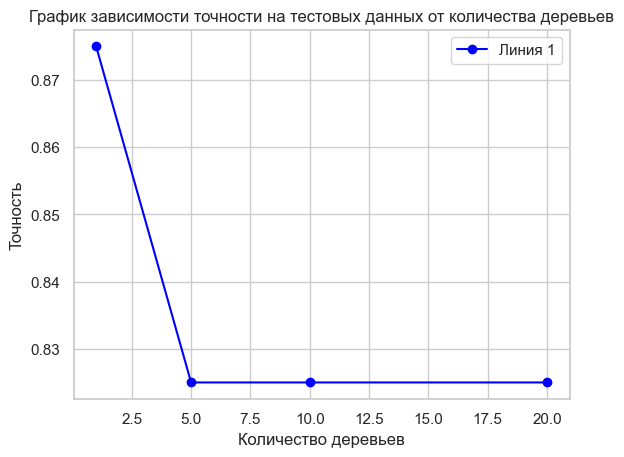

In [188]:
# Создание графика
trees_count = [len([bootstrap_tree]), len(trees_5), len(trees_10), len(trees_20)]
accuracy_forest = [metrics.accuracy_score(y_test, y_test_pred), metrics.accuracy_score(y_test, y_test_pred_trees_5), metrics.accuracy_score(y_test, y_test_pred_trees_10), metrics.accuracy_score(y_test, y_test_pred_trees_20)]
plt.plot(trees_count, accuracy_forest, marker='o', color='blue', label='Линия 1')

# Добавление оформления
plt.title("График зависимости точности на тестовых данных от количества деревьев")
plt.xlabel("Количество деревьев")
plt.ylabel("Точность")
plt.grid(True) # Сетка
plt.legend()   # Легенда

# Отображение
plt.show()

##### 4. Результат

 4.1. Таблица с точностью (accuracy) на обучении и тесте при построении деревьев.
$$
\begin{array}{|c|c|c|c|c|}
\hline \text{N} & 1 & 5 & 10 & 20 \\ 
\hline \text{Training accuracy} & 0.919 & 1.000 & 1.000 & 1.000\\
\hline \text{Test accuracy} & 0.875 & 0.825 & 0.825 & 0.825\\
\hline
\end{array}
$$

4.2. Вывод

Мы видим как с увеличением числа деревьев в ансамбле тестовая точность снизилась, хотя должна расти. Это может объяснятся малым размером выборки. На малой выборке количество уникальных бутстрэп-подвыборок  ограничено. Деревья начинают сильно коррелировать между собой, становясь почти идентичными. Каждое дерево подстраивается под специфические выбросы в своей подвыборке. При росте их числа ансамбль может просто «заучить» шум исходной маленькой выборки, это может подтверждаться значениями точности на обучающих данных, точность в 100 % может говорить о том, что модель "заучила" выборку, а не обучилась на ней.

В итоге, если данных мало, деревья получаются либо слишком смещенными, либо слишком скоррелированными, что ведет к деградации качества при чрезмерном увеличении размера ансамбля.




# Этап 3. Кластеризация и понижение размерности (15 баллов)
Вы переходите к задаче кластеризации, в которой исследуете, как разные методы группируют данные.

#### Что нужно сделать

#### 1. Загрузите набор данных:

from sklearn.datasets import load_iris

data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)

#### 2. Перед кластеризацией выполните масштабирование признаков (например, z-score), так как признаки имеют разные масштабы, а k-means чувствителен к ним:

X = (X - X.mean()) / X.std()

#### 3. Реализуйте вручную алгоритм k-means:

инициализируйте центры кластеров случайным образом (зафиксируйте random_state для воспроизводимости);

назначайте точки ближайшему центру;

пересчитывайте центры;

останавливайте итерации, когда сдвиг центров становится меньше tolerance (например, 1e-4) или достигнут максимум итераций.

#### 4. Примените метод PCA (собственная реализация через numpy.linalg) для снижения размерности до 2D.

Визуализация

Постройте точки данных на плоскости после PCA.

Раскрасьте их по кластерам.

Обозначьте центры кластеров.

Сравните результат с KMeans из sklearn.

Учитывайте, что порядок кластеров может различаться — сопоставьте центры по минимальному попарному расстоянию или сравните визуально на графике.

#### Результат

График кластеров после снижения размерности.

Сравнение центров кластеров вашей и sklearn-версий (с корректным сопоставлением кластеров).

Краткий вывод о различиях и качестве кластеризации.

#### 1.Загружаем набор данных. Выполняем масштабирование признаков:

In [189]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
X = (X - X.mean()) / X.std()

#### 2. Применение PCA для снижения размерности до 2D

In [190]:
# Данные уже стандартизированы. Строим ковариционную матрицу.
cov_mat = np.cov(X, rowvar=False)

# Далее находим собственные значения и собственные векторы для матрицы ковариаций.
eigen_val, eigen_vectors = np.linalg.eig(cov_mat)

# Нужно взять 2 вектора с наибольшими собственными значениями. 
# При нахождении собственных векторов в Python они выводятся в соответствии с убыванием соответствующих собственных значений, 
# поэтому берём первые два вектора
eigen_vectors = eigen_vectors[:,[0, 1]]

# Перемножаем матрицу стандартизированных признаков на матрицу с собственными векторами и получаем матрицу главных компонент
principalComponents_manual = np.dot(X, eigen_vectors)

#### 3. Строим диаграмму точек данных после PCA.

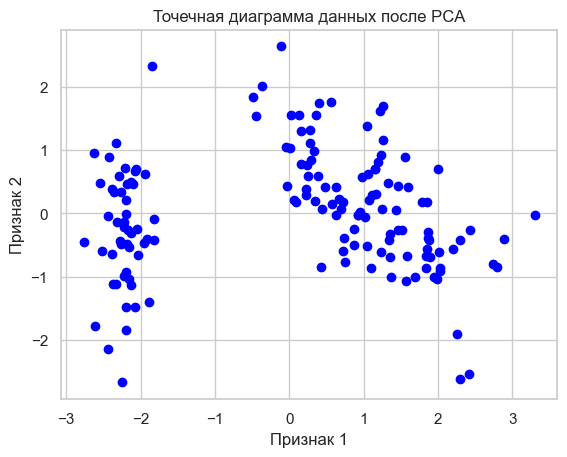

In [195]:
plt.scatter(principalComponents_manual[:, 0], principalComponents_manual[:, 1], color='blue', marker='o')

plt.title("Точечная диаграмма данных после PCA")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")

plt.show()

#### 4. Реализация алгоритма k-means вручную.

In [196]:
class ManualKMeans:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None
        self.inertia_ = None
        self.labels_ = None

    # sklearn-совместимые методы:
    def get_params(self, deep=True):
        """
        Возвращает параметры конструктора (нужно для sklearn.clone)
        """
        return {
            "n_clusters": self.n_clusters,
            "max_iter": self.max_iter,
            "tol": self.tol,
            "random_state": self.random_state
        }

    def set_params(self, **params):
        """
        Устанавливает параметры и возвращает self (как у sklearn)
        """
        allowed = {"n_clusters", "max_iter", "tol", "random_state"}
        for k, v in params.items():
            if k not in allowed:
                raise ValueError(f"Unknown parameter '{k}' for ManualKMeans")
            setattr(self, k, v)
        return self

    def _init_centers(self, X):
        """
        Начальная инициализация (случайная)
        """
        # X = np.asarray(X)
        n_samples = X.shape[0]
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters is larger than number of samples")
        # случайная инициализация
        rng = np.random.RandomState(self.random_state)
        indices = rng.choice(n_samples, self.n_clusters, replace=False)
        return X[indices].astype(float)

    def fit(self, X, y=None):
        """
        Обучение модели
        """
        X = np.asarray(X)  # Преобразуем входные данные в numpy-массив
        centers = self._init_centers(X)  # Инициализация центров кластеров

        for i in range(int(self.max_iter)):  # Основной цикл итераций K-Means
            dists = cdist(X, centers, metric='euclidean')  # Вычисляем расстояния точек до центров
            labels = np.argmin(dists, axis=1)  # Назначаем каждой точке ближайший центр
            new_centers = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
                for k in range(self.n_clusters)
            ])  # Обновляем центры как среднее точек каждого кластера

            shift = np.linalg.norm(new_centers - centers)  # Считаем изменение центров
            centers = new_centers
            if shift <= float(self.tol):  # Проверяем условие сходимости
                break

        # Сохраняем результаты обучения
        self.cluster_centers_ = centers
        self.labels_ = labels
        self.inertia_ = float(np.sum((X - centers[labels]) ** 2))  # Сумма квадратов расстояний до центров
        return self


    def predict(self, X):
        if self.cluster_centers_ is None:
            raise ValueError("Model is not fitted yet. Call fit() before predict().")
        dists = cdist(np.asarray(X), self.cluster_centers_)
        return np.argmin(dists, axis=1)

    def fit_predict(self, X, y=None):
        self.fit(X)
        return self.labels_

#### 5. Обучаем модель ManualKMeans, отображаем на графике получившиеся кластеры и центроиды кластеров.

In [193]:
model_manual = ManualKMeans(random_state=42)
labels_manual = model_manual.fit_predict(principalComponents_manual)
centers_manual = model_manual.cluster_centers_

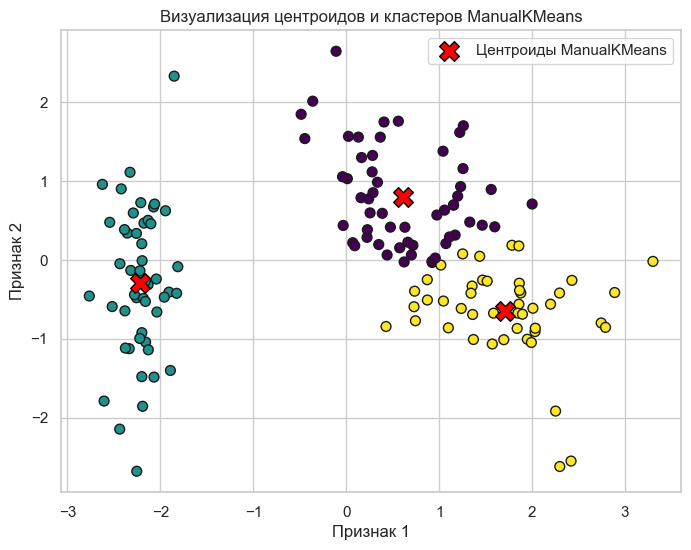

In [197]:
plt.figure(figsize=(8, 6))
plt.scatter(principalComponents_manual[:, 0], 
            principalComponents_manual[:, 1], 
            c=labels_manual,           
            cmap='viridis',     
            edgecolor='k', 
            s=50)

plt.scatter(centers_manual[:, 0], 
            centers_manual[:, 1], 
            c='red',           
            marker='X',        
            s=200,             
            label='Центроиды ManualKMeans', 
            edgecolor='black')

plt.title('Визуализация центроидов и кластеров ManualKMeans')
plt.legend()
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')

plt.show()

#### 6. Обучаем модели KMeans из sklearn, с разными методами выбора центроидов для сравнения.

In [198]:
model_sklearn_k_means_plus = KMeans(n_clusters=3, random_state=42)
labels_sklearn_k_means_plus = model_sklearn_k_means_plus.fit_predict(principalComponents_manual)
centers_sklearn_k_means_plus = model_sklearn_k_means_plus.cluster_centers_

In [199]:
model_sklearn_k_means_random = KMeans(n_clusters=3, random_state=42, init='random')
labels_sklearn_k_means_random = model_sklearn_k_means_random.fit_predict(principalComponents_manual)
centers_sklearn_k_means_random = model_sklearn_k_means_random.cluster_centers_

#### 7. Визуально сравниваем центры кластеров.

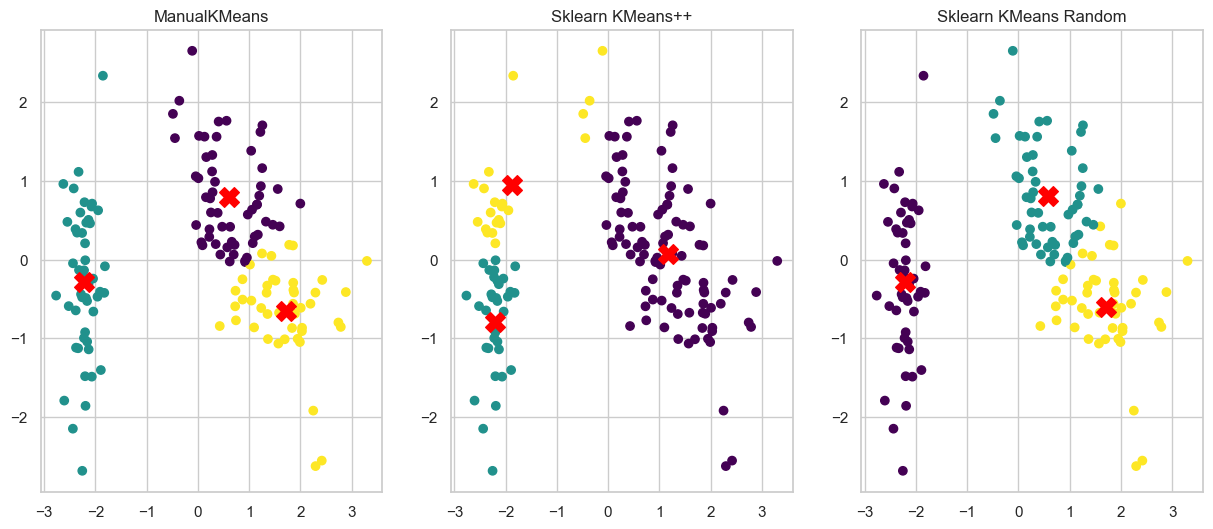

In [200]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))

# ManualKMeans
ax1.scatter(principalComponents_manual[:, 0], principalComponents_manual[:, 1], c=labels_manual, cmap='viridis')
ax1.scatter(model_manual.cluster_centers_[:, 0], model_manual.cluster_centers_[:, 1], c='red', marker='X', s=200)
ax1.set_title("ManualKMeans")

# Sklearn KMeans++
ax2.scatter(principalComponents_manual[:, 0], principalComponents_manual[:, 1], c=labels_sklearn_k_means_plus, cmap='viridis')
ax2.scatter(model_sklearn_k_means_plus.cluster_centers_[:, 0], model_sklearn_k_means_plus.cluster_centers_[:, 1], c='red', marker='X', s=200)
ax2.set_title("Sklearn KMeans++")

# Sklearn KMeans Random
ax3.scatter(principalComponents_manual[:, 0], principalComponents_manual[:, 1], c=labels_sklearn_k_means_random, cmap='viridis')
ax3.scatter(model_sklearn_k_means_random.cluster_centers_[:, 0], model_sklearn_k_means_random.cluster_centers_[:, 1], c='red', marker='X', s=200)
ax3.set_title("Sklearn KMeans Random")

plt.show()

#### 8. Рассчитываем коэффициент силуэта для сравнения качества классификации

In [201]:
sil_manual = silhouette_score(principalComponents_manual, labels_manual)
sil_plus = silhouette_score(principalComponents_manual, labels_sklearn_k_means_plus)
sil_random = silhouette_score(principalComponents_manual, labels_sklearn_k_means_random)

sil_manual, sil_plus, sil_random

(0.5113245176460451, 0.5227910941742376, 0.5091683341538228)

#### 9. Краткий вывод о различиях и качестве кластеризации.

Известно, что в датасете Iris 3 вида ирисов. Поэтому будем использовать разделение на 3 кластера. Хотя на графике после применения PCA заметно, что визуально точки лучше разделятся на 2 кластера. 

Были обучены три модели кластеризации K-means: на алгоритме, построенном вручную; на библиотечном алгоритме из sklearn с применением алгоритма K-means++; а также на библиотечном алгоритме из sklearn с применением алгоритма random для лучшего понимания различий кластеризации между ручным и библиотечным алгоритмом.

При визуальном сравнении ручного алгоритма и алгоритма K-means++ заметно различие в определении центроидов и границ кластеров, это объясняется различными алгоритмами начального выбора центроидов моделей. Это также подтверждается результатами кластеризации sklearn алгоритма с методом выбора центроидов - random, такой же метод использован в ручном алгоритме. Заметно, что результаты ручного алгоритма и алгоритма random идентичны. 

Однако, несмотря на визуальные различия в границах кластеров, идентичный коэффициент силуэта указывает на математическую равнозначность всех моделей. Различия обусловлены разной инициализацией центроидов. Следовательно относительное качество кластеризации всех моделей идентично.


# Этап 4. Итоговый анализ (5 баллов)
На этом этапе вы подводите итоги и анализируете результаты всех предыдущих шагов.

Что нужно сделать

В конце ноутбука оформите краткий раздел «Итоги» в виде 2-3 абзацев или маркированного списка.

Ответьте на следующие вопросы:

Что общего у дерева решений, ансамбля и кластеризации с точки зрения принципов разделения данных и интерпретации результатов?

Как параметры (глубина дерева, количество деревьев, число кластеров и др.) влияли на результаты?

Какие трудности возникли при реализации алгоритмов и как вы их решали?

Как вы проверяли корректность своих алгоритмов и воспроизводимость экспериментов (например, фиксирование random_state, сравнение со sklearn)?

Результат

Краткий структурированный текстовый вывод в конце ноутбука, отражающий:

понимание принципов работы изученных алгоритмов;

осознанную оценку параметров и ограничений;

выводы о собственном опыте реализации и анализа моделей.

#### 1. Что общего у дерева решений, ансамбля и кластеризации с точки зрения принципов разделения данных и интерпретации результатов?

Дерево решений, ансамбли и кластеризация выполняют разбиение пространства данных на более однородные подмножества. С геометрической точки зрения дерево решений представляет собой разделение пространства данных на гиперпрямоугольники, где каждый разрез от корневого узла до конечного узла формирует определенную область. Методы кластеризации также разбивают данные на подмножества, минимизируя расстояние внутри кластера и максимизируя расстояние между кластерами. Ансамбли используют множественные разделения данных через комбинацию базовых моделей, каждая из которых выполняет собственное разбиение пространства признаков. Все методы стремятся к созданию максимально однородных групп. 

#### 2. Как параметры (глубина дерева, количество деревьев, число кластеров и др.) влияли на результаты?

Глубина дерева влияла на точность предсказаний. Малая глубина ведет к недообучению, в таком случае дерево не может уловить сложные зависимости. Большая глубина, в свою очередь, ведет к переобучению. Дерево разрастается, запоминая шум и выбросы, и плохо предсказывает резульататы на новых данных. 

Увеличение количества деревьев в ансамбле в нашем случае привело к переобучению модели из-за маленькой выборки. Но в теории, увеличение количества деревьев улучшает стабильность.

#### 3. Какие трудности возникли при реализации алгоритмов и как вы их решали?

В процессе выполнения работы возникали трудности с интерпретацией результатов. Необходимо было самостоятельно изучить особенности алгоритмов, их преимущества и недостатки для корректной реализации и интерпретации результатов.

#### 4. Как вы проверяли корректность своих алгоритмов и воспроизводимость экспериментов (например, фиксирование random_state, сравнение со sklearn)?

Для воспроизводимости экспериментов фиксировался random_state, это позволяет получать один и тот же результат при разных запусках кода, а так же получать сравнимые результаты при сравнении результатов разных алгоритмов при одном и том же процессе, например, при кластеризации ручным и библиотечным алгоритмом.
Также производилось сравнение вручную написанных алгоритмов с библиотечными функциями, что позволяло проверить корректность результатов ручных алгоритмов.

